In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data types:")
print(df.dtypes)
df.head()

KeyboardInterrupt: 

In [1]:
# Score each dimension 1-5 using quintiles (5 equal-sized buckets)

# Recency: LOWER is better (recent = good), so best recency gets score 5.
# We reverse the labels: smallest days -> 5, largest days -> 1
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: HIGHER is better. We rank first to break ties, then cut into 5.
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: HIGHER is better.
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine into an overall RFM score (sum, ranges 3-15)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))
print("\nRFM_Score distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np

# Reload clean data
df = pd.read_csv('../data/processed/online_retail_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Build RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

# Score 1-5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
           'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))
print("\nRFM_Score distribution:")
print(rfm['RFM_Score'].value_counts().sort_index())

   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2          7   4310.00        5        5        5   
2       12348       75          4   1797.24        2        4        4   
3       12349       19          1   1757.55        4        1        4   
4       12350      310          1    334.40        1        1        2   
5       12352       36          8   2506.04        3        5        5   
6       12353      204          1     89.00        1        1        1   
7       12354      232          1   1079.40        1        1        4   
8       12355      214          1    459.40        1        1        2   
9       12356       23          3   2811.43        4        3        5   

   RFM_Score  
0          7  
1         15  
2         10  
3          9  
4          4  
5         13  
6          3  
7          6  
8          4  
9         12  

RFM_Score distribut

In [4]:
# Map RFM scores into named business segments based on R and F.
# We use a function that looks at the Recency and Frequency scores
# to assign each customer a meaningful label.

def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'          # recent + frequent = your best
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'    # solid regulars
    elif r >= 4 and f <= 2:
        return 'New Customers'      # bought recently, not often yet
    elif r >= 3 and f <= 2:
        return 'Promising'          # fairly recent, low frequency
    elif r <= 2 and f >= 3:
        return 'At Risk'            # used to buy often, gone quiet — WIN BACK
    elif r <= 2 and f <= 2:
        return 'Lost'               # gone, infrequent
    else:
        return 'Needs Attention'    # everyone else

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# How many customers in each segment?
print("Customers per segment:")
print(rfm['Segment'].value_counts())

# Average R, F, M per segment — this is the business-interpretation table
print("\nSegment profiles (averages):")
print(rfm.groupby('Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count')
).round(1).sort_values('Avg_Monetary', ascending=False))

Customers per segment:
Segment
Champions          1139
Lost               1065
Loyal Customers     821
At Risk             643
Promising           351
New Customers       319
Name: count, dtype: int64

Segment profiles (averages):
                 Avg_Recency  Avg_Frequency  Avg_Monetary  Count
Segment                                                         
Champions               13.3           10.0        5204.3   1139
Loyal Customers         38.0            3.6        1651.3    821
At Risk                152.8            3.4        1245.0    643
Lost                   217.9            1.1         487.7   1065
Promising               53.5            1.2         461.1    351
New Customers           18.5            1.2         458.2    319


In [5]:
# Save the RFM table with scores and segments for Day 3 clustering
rfm.to_csv('../data/processed/rfm_features.csv', index=False)
print("Saved RFM features:", rfm.shape)
print("Columns:", rfm.columns.tolist())

Saved RFM features: (4338, 9)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [ ]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

Missing values per column:


NameError: name 'df' is not defined

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/online_retail.xlsx', engine='openpyxl')

print("Missing values per column:")
print(df.isnull().sum())

print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

df.describe()

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Percentage missing:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
# Start from the raw data, make a copy so we keep the original intact
df_clean = df.copy()

# 1. Drop rows with no CustomerID — needed for segmentation & churn
df_clean = df_clean.dropna(subset=['CustomerID'])

# 2. Drop rows with no product Description (junk rows)
df_clean = df_clean.dropna(subset=['Description'])

# 3. Remove returns/cancellations — keep only real sales (Quantity > 0)
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Remove zero/negative prices — not valid sales
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 5. CustomerID should be a whole number, not 17850.0 — convert to int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 6. Create a TotalPrice column — useful for revenue analysis & RFM later
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Compare before and after
print("Original rows:", len(df))
print("Cleaned rows: ", len(df_clean))
print("Rows removed: ", len(df) - len(df_clean), 
      f"({(len(df)-len(df_clean))/len(df)*100:.1f}%)")
print("\nCleaned data check:")
print(df_clean.describe())

Original rows: 541909
Cleaned rows:  397884
Rows removed:  144025 (26.6%)

Cleaned data check:
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID     TotalPrice  
count  397884.000000  397884.000000  
mean    15294.423453      22.397000  
min     12346.000000       0.001000  
25%     13969.000000       4.680000  
50%     15159.000000      11.800000  
75%     16795.000000      19.800000  
max     

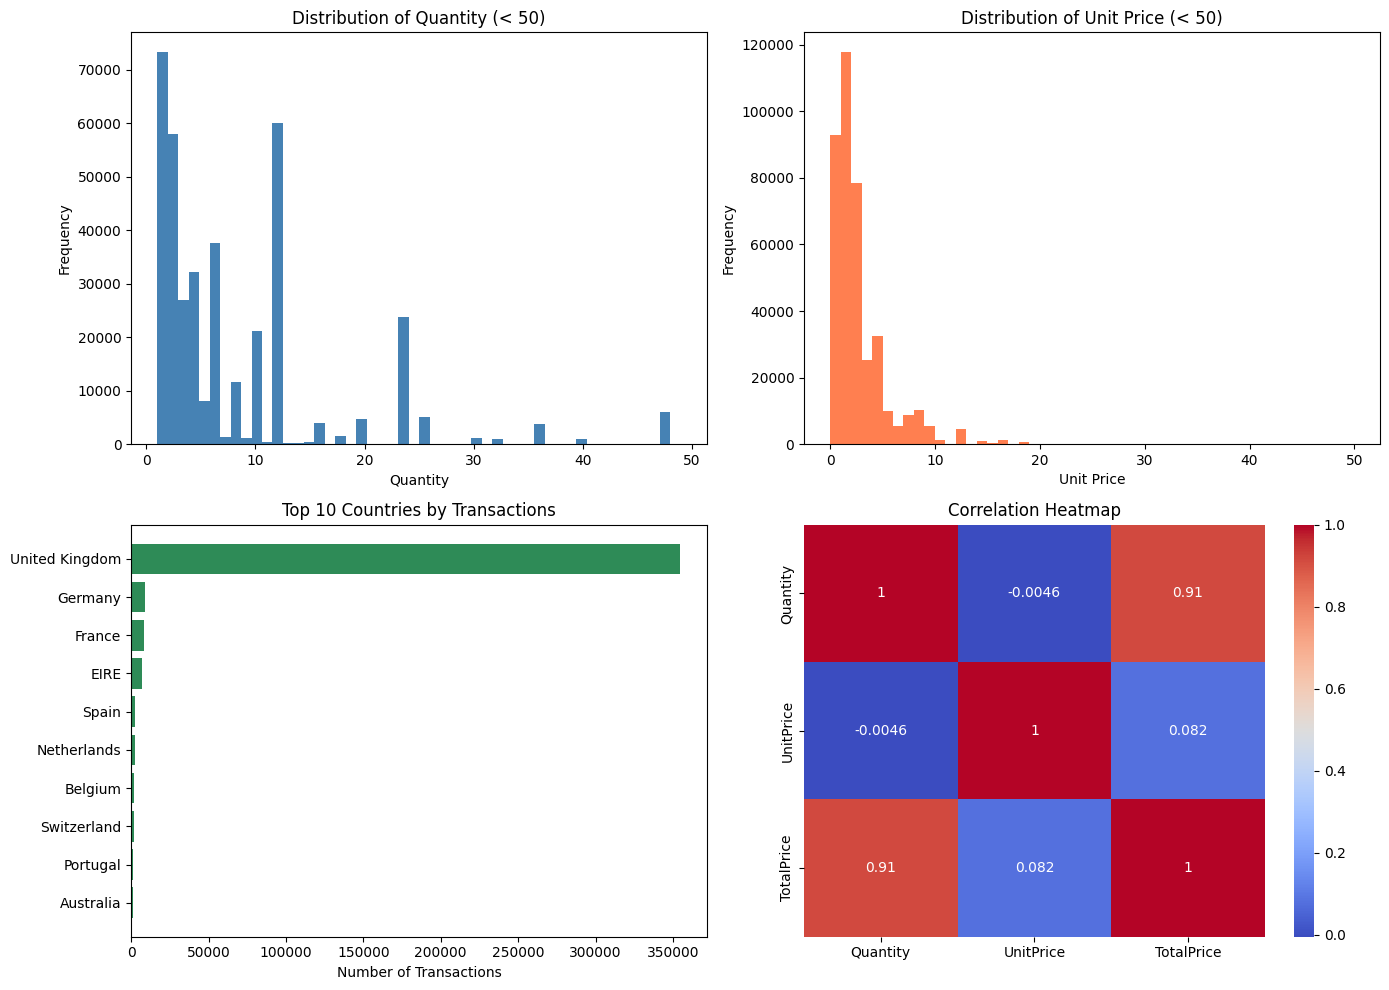

In [ ]:
# Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Quantity (capped at 50 to see the bulk, not outliers)
axes[0,0].hist(df_clean[df_clean['Quantity'] < 50]['Quantity'], bins=50, color='steelblue')
axes[0,0].set_title('Distribution of Quantity (< 50)')
axes[0,0].set_xlabel('Quantity'); axes[0,0].set_ylabel('Frequency')

# 2. Distribution of UnitPrice (capped at 50)
axes[0,1].hist(df_clean[df_clean['UnitPrice'] < 50]['UnitPrice'], bins=50, color='coral')
axes[0,1].set_title('Distribution of Unit Price (< 50)')
axes[0,1].set_xlabel('Unit Price'); axes[0,1].set_ylabel('Frequency')

# 3. Top 10 countries by number of transactions
top_countries = df_clean['Country'].value_counts().head(10)
axes[1,0].barh(top_countries.index[::-1], top_countries.values[::-1], color='seagreen')
axes[1,0].set_title('Top 10 Countries by Transactions')
axes[1,0].set_xlabel('Number of Transactions')

# 4. Correlation heatmap of numeric columns
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('../models/eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()

In [6]:
# Save cleaned data so Day 2 can load it instantly
df_clean.to_csv('../data/processed/online_retail_clean.csv', index=False)
print("Saved! Shape:", df_clean.shape)

Saved! Shape: (397884, 9)


In [7]:
import pandas as pd
import numpy as np

# Load the cleaned data we saved in Day 1
df = pd.read_csv('../data/processed/online_retail_clean.csv')

# CSV doesn't remember dates are dates, so convert InvoiceDate back to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Loaded:", df.shape)
df.head()

Loaded: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [8]:
# Set a "snapshot date" = the day after the last transaction.
# We pretend we're analyzing the data one day after the last sale,
# so Recency = days between a customer's last purchase and this date.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Group by customer and compute R, F, M
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),   # count of distinct orders
    Monetary  = ('TotalPrice',  'sum')        # total money spent
).reset_index()

print("\nRFM table shape:", rfm.shape)
print(rfm.head())
print("\nRFM summary:")
print(rfm.describe())

Snapshot date: 2011-12-10 12:50:00

RFM table shape: (4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

RFM summary:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000
